# Supply Chain Data Cleaning

This notebook performs data cleaning and preprocessing on the supply chain dataset to prepare it for exploratory data analysis and business insights.

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(
    "../data/raw/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

In [5]:
df.shape


(180519, 53)

In [6]:
df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [8]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [9]:
df.duplicated().sum()


np.int64(0)

In [10]:
selected_columns = [
    'Order Id',
    'order date (DateOrders)',
    'shipping date (DateOrders)',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Delivery Status',
    'Late_delivery_risk',
    'Sales',
    'Order Item Quantity',
    'Category Name',
    'Product Name',
    'Order Region',
    'Shipping Mode',
    'Order Profit Per Order',
    'Customer Segment'
]

In [11]:
df[selected_columns].info()


<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Order Id                       180519 non-null  int64  
 1   order date (DateOrders)        180519 non-null  str    
 2   shipping date (DateOrders)     180519 non-null  str    
 3   Days for shipping (real)       180519 non-null  int64  
 4   Days for shipment (scheduled)  180519 non-null  int64  
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Sales                          180519 non-null  float64
 8   Order Item Quantity            180519 non-null  int64  
 9   Category Name                  180519 non-null  str    
 10  Product Name                   180519 non-null  str    
 11  Order Region                   180519 non-null  str    
 12  Shipping Mode                  180519 non

In [12]:
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)']
)

df['shipping date (DateOrders)'] = pd.to_datetime(
    df['shipping date (DateOrders)']
)

In [13]:
df[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes


order date (DateOrders)       datetime64[us]
shipping date (DateOrders)    datetime64[us]
dtype: object

In [14]:
df[['Days for shipping (real)', 'Days for shipment (scheduled)']].describe()

,Days for shipping (real),Days for shipment (scheduled)
count,180519.000000,180519.000000
mean,3.497654,2.931847
std,1.623722,1.374449
min,0.000000,0.000000
25%,2.000000,2.000000
50%,3.000000,4.000000
75%,5.000000,4.000000
max,6.000000,4.000000


In [15]:
df[['Sales', 'Order Profit Per Order']].describe()


,Sales,Order Profit Per Order
count,180519.000000,180519.000000
mean,203.772096,21.974989
std,132.273077,104.433526
min,9.990000,-4274.979980
25%,119.980003,7.000000
50%,199.919998,31.520000
75%,299.950012,64.800003
max,1999.989990,911.799988


In [16]:
df['Order Item Quantity'].describe()

count    180519.000000
mean          2.127638
std           1.453451
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           5.000000
Name: Order Item Quantity, dtype: float64

In [17]:
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [18]:
df['Shipping Mode'].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [19]:
df['Customer Segment'].value_counts()

Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

In [20]:
df['Shipping_Delay_Days'] = (
    df['Days for shipping (real)'] -
    df['Days for shipment (scheduled)']
)

In [21]:
df['Shipping_Delay_Days'].describe()


count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Shipping_Delay_Days, dtype: float64

In [22]:
df['Shipping_Delay_Days'].value_counts().sort_index()

Shipping_Delay_Days
-2    21666
-1    21700
 0    33753
 1    60647
 2    28718
 3     7052
 4     6983
Name: count, dtype: int64

In [23]:
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [24]:
df['Shipping Mode'].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [25]:
df['Order Region'].value_counts()

Order Region
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West of USA         7993
South Asia          7731
Eastern Asia        7280
East of USA         6915
West Asia           6009
US Center           5887
South of  USA       4045
Eastern Europe      3920
West Africa         3696
North Africa        3232
East Africa         1852
Central Africa      1677
Southern Africa     1157
Canada               959
Central Asia         553
Name: count, dtype: int64

In [26]:
df['Customer Segment'].value_counts()

Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

In [27]:
df['Late_delivery_risk'].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [28]:
df['Order Id'].nunique()

65752

In [29]:
pd.crosstab(
    df['Delivery Status'],
    df['Late_delivery_risk']
)

Late_delivery_risk,0,1
Delivery Status,,
Advance shipping,41592,0
Late delivery,0,98977
Shipping canceled,7754,0
Shipping on time,32196,0


In [30]:
pd.crosstab(
    df['Shipping_Delay_Days'],
    df['Delivery Status']
)

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Shipping_Delay_Days,,,,
-2,20873,0,793,0
-1,20719,0,981,0
0,0,0,1557,32196
1,0,57957,2690,0
2,0,27551,1167,0
3,0,6772,280,0
4,0,6697,286,0


In [31]:
id="c5c1m7"
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [32]:
delivery_percentage = (
    df['Delivery Status'].value_counts(normalize=True) * 100
)

delivery_percentage

Delivery Status
Late delivery        54.829132
Advance shipping     23.040234
Shipping on time     17.835242
Shipping canceled     4.295393
Name: proportion, dtype: float64

In [33]:
shipping_delivery_pct = pd.crosstab(
    df['Shipping Mode'],
    df['Delivery Status'],
    normalize='index'
) * 100

shipping_delivery_pct.round(2)

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Shipping Mode,,,,
First Class,0.0,95.32,4.68,0.00
Same Day,0.0,45.74,4.56,49.70
Second Class,0.0,76.63,4.00,19.36
Standard Class,38.6,38.07,4.27,19.06


In [34]:
late_by_shipping = (
    df.groupby('Shipping Mode')['Late_delivery_risk']
    .mean() * 100
)

late_by_shipping.round(2)

Shipping Mode
First Class       95.32
Same Day          45.74
Second Class      76.63
Standard Class    38.07
Name: Late_delivery_risk, dtype: float64

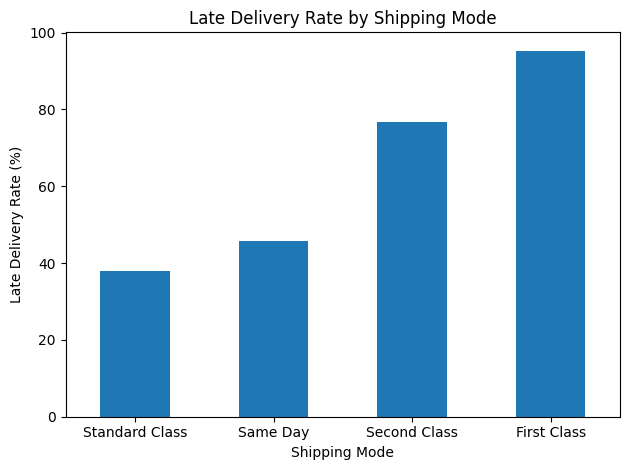

In [35]:
import matplotlib.pyplot as plt

late_by_shipping.sort_values().plot(kind='bar')

plt.title('Late Delivery Rate by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
late_by_region = (
    df.groupby('Order Region')['Late_delivery_risk']
    .mean() * 100
)

late_by_region.round(2)

Order Region
Canada             48.80
Caribbean          53.08
Central Africa     57.96
Central America    54.75
Central Asia       55.33
East Africa        55.94
East of USA        55.66
Eastern Asia       54.33
Eastern Europe     55.66
North Africa       54.52
Northern Europe    54.04
Oceania            54.02
South America      54.31
South Asia         56.27
South of  USA      55.77
Southeast Asia     55.53
Southern Africa    53.33
Southern Europe    54.38
US Center          55.24
West Africa        52.84
West Asia          55.28
West of USA        53.96
Western Europe     55.85
Name: Late_delivery_risk, dtype: float64

In [37]:
late_by_region.sort_values(ascending=False).round(2)

Order Region
Central Africa     57.96
South Asia         56.27
East Africa        55.94
Western Europe     55.85
South of  USA      55.77
Eastern Europe     55.66
East of USA        55.66
Southeast Asia     55.53
Central Asia       55.33
West Asia          55.28
US Center          55.24
Central America    54.75
North Africa       54.52
Southern Europe    54.38
Eastern Asia       54.33
South America      54.31
Northern Europe    54.04
Oceania            54.02
West of USA        53.96
Southern Africa    53.33
Caribbean          53.08
West Africa        52.84
Canada             48.80
Name: Late_delivery_risk, dtype: float64

In [38]:
late_by_region.sort_values(ascending=False).head(5).round(2)

Order Region
Central Africa    57.96
South Asia        56.27
East Africa       55.94
Western Europe    55.85
South of  USA     55.77
Name: Late_delivery_risk, dtype: float64

In [39]:
late_by_region.sort_values(ascending=True).head(5).round(2)

Order Region
Canada             48.80
West Africa        52.84
Caribbean          53.08
Southern Africa    53.33
West of USA        53.96
Name: Late_delivery_risk, dtype: float64

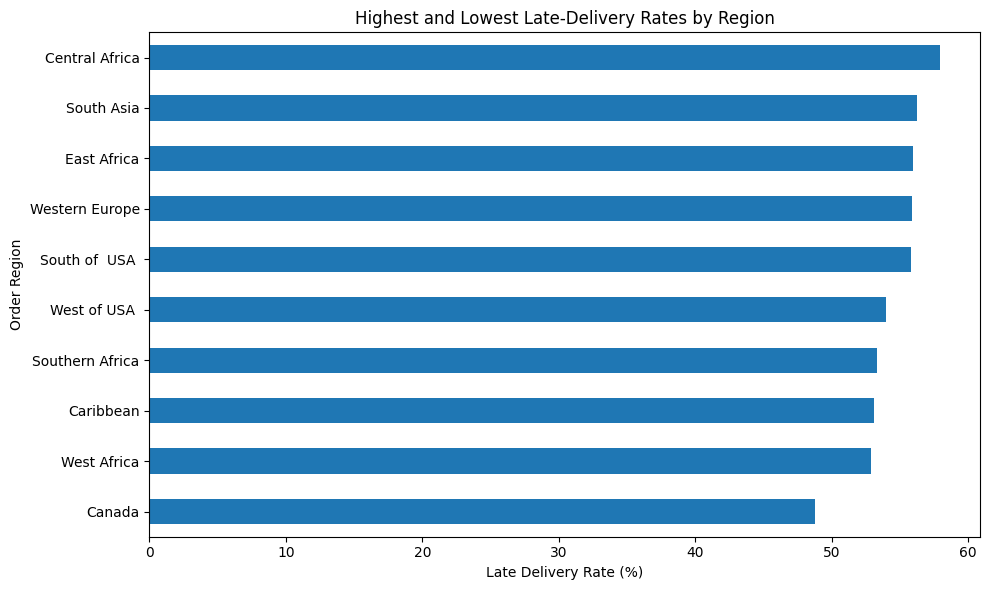

In [40]:
region_extremes = pd.concat([
    late_by_region.sort_values(ascending=False).head(5),
    late_by_region.sort_values(ascending=True).head(5)
]).sort_values()

region_extremes.plot(kind='barh', figsize=(10, 6))

plt.title('Highest and Lowest Late-Delivery Rates by Region')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Order Region')
plt.tight_layout()
plt.show()

In [41]:
late_by_category = (
    df.groupby('Category Name')['Late_delivery_risk']
    .mean() * 100
)

In [42]:
late_by_category.sort_values(ascending=False).round(2)

Category Name
Golf Bags & Carts       68.85
Lacrosse                60.06
Pet Supplies            58.94
Cameras                 58.11
Strength Training       57.66
As Seen on  TV!         57.35
Music                   57.14
Accessories             56.97
Fitness Accessories     56.96
Books                   56.54
Women's Clothing        56.46
Boxing & MMA            56.26
Golf Gloves             56.26
Hunting & Shooting      56.14
Electronics             56.08
Crafts                  55.99
Health and Beauty       55.80
Tennis & Racquet        55.79
Garden                  55.79
Trade-In                55.65
Golf Shoes              55.53
Sporting Goods          55.46
Girls' Apparel          55.29
Basketball              55.22
Baseball & Softball     55.22
Consumer Electronics    55.22
Shop By Sport           55.15
Toys                    55.01
Cleats                  54.97
Fishing                 54.93
Water Sports            54.81
Indoor/Outdoor Games    54.75
Golf Balls              54

In [43]:
late_by_category.sort_values(ascending=False).head(5).round(2)

Category Name
Golf Bags & Carts    68.85
Lacrosse             60.06
Pet Supplies         58.94
Cameras              58.11
Strength Training    57.66
Name: Late_delivery_risk, dtype: float64

In [44]:
late_by_category.sort_values(ascending=True).head(5).round(2)

Category Name
Men's Golf Clubs    47.70
Computers           50.68
Golf Apparel        51.93
CDs                 52.03
Baby                52.66
Name: Late_delivery_risk, dtype: float64

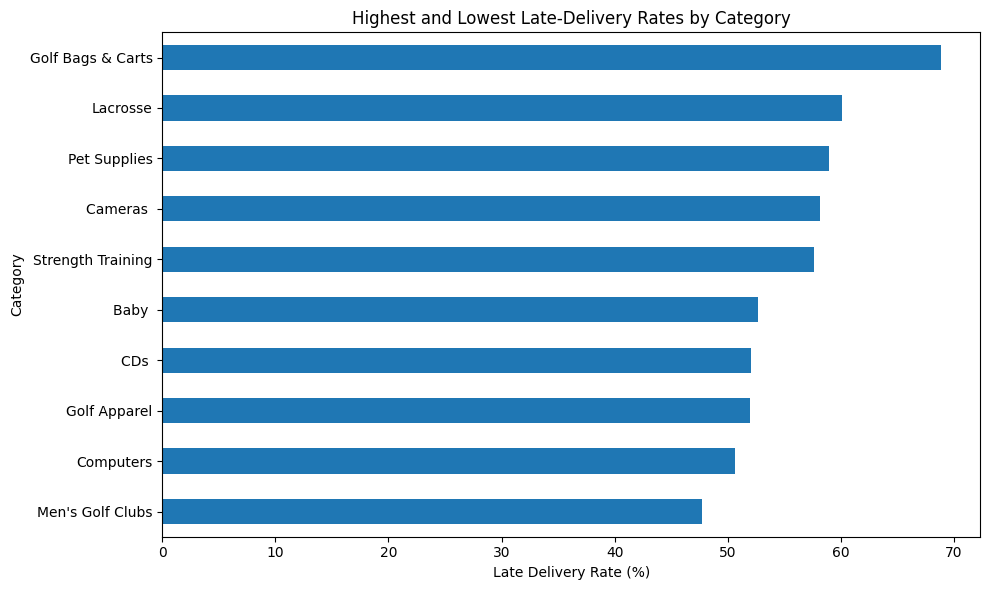

In [45]:
category_extremes = pd.concat([
    late_by_category.sort_values(ascending=False).head(5),
    late_by_category.sort_values(ascending=True).head(5)
]).sort_values()

category_extremes.plot(kind='barh', figsize=(10, 6))

plt.title('Highest and Lowest Late-Delivery Rates by Category')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [46]:
profit_by_delivery = (
    df.groupby('Late_delivery_risk')['Order Profit Per Order']
    .mean()
)

profit_by_delivery.round(2)

Late_delivery_risk
0    22.40
1    21.62
Name: Order Profit Per Order, dtype: float64

In [47]:
sales_by_delivery = (
    df.groupby('Late_delivery_risk')['Sales']
    .mean()
)

sales_by_delivery.round(2)

Late_delivery_risk
0    204.29
1    203.34
Name: Sales, dtype: float64

In [48]:
late_by_segment = (
    df.groupby('Customer Segment')['Late_delivery_risk']
    .mean() * 100
)

late_by_segment.sort_values(ascending=False).round(2)

Customer Segment
Home Office    55.07
Consumer       54.81
Corporate      54.72
Name: Late_delivery_risk, dtype: float64

In [49]:
df['Order_Month'] = df['order date (DateOrders)'].dt.to_period('M')


## Final Data Validation

The cleaned dataset is validated to confirm that the required preprocessing and feature engineering steps have been completed successfully.

In [76]:
df.shape

(180519, 55)

In [102]:
df.isnull().sum().sum()

np.int64(336209)

In [167]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

In [195]:
columns_to_drop = [
    'Product Description',
    'Order Zipcode',
    'Customer Lname',
    'Customer Zipcode'
]

df.drop(columns=columns_to_drop, inplace=True)

In [223]:
df.shape

(180519, 51)

In [250]:
df.isnull().sum().sum()

np.int64(0)

In [251]:
df.duplicated().sum()

np.int64(0)

In [278]:
df.dtypes

Type                                        str
Days for shipping (real)                  int64
Days for shipment (scheduled)             int64
Benefit per order                       float64
Sales per customer                      float64
Delivery Status                             str
Late_delivery_risk                        int64
Category Id                               int64
Category Name                               str
Customer City                               str
Customer Country                            str
Customer Email                              str
Customer Fname                              str
Customer Id                               int64
Customer Password                           str
Customer Segment                            str
Customer State                              str
Customer Street                             str
Department Id                             int64
Department Name                             str
Latitude                                

In [305]:
df[['order date (DateOrders)',
    'shipping date (DateOrders)',
    'Shipping_Delay_Days',
    'Order_Month']].head()

,order date (DateOrders),shipping date (DateOrders),Shipping_Delay_Days,Order_Month
0,2018-01-31 22:56:00,2018-02-03 22:56:00,-1,2018-01
1,2018-01-13 12:27:00,2018-01-18 12:27:00,1,2018-01
2,2018-01-13 12:06:00,2018-01-17 12:06:00,0,2018-01
3,2018-01-13 11:45:00,2018-01-16 11:45:00,-1,2018-01
4,2018-01-13 11:24:00,2018-01-15 11:24:00,-2,2018-01


In [306]:
monthly_late_rate = (
    df.groupby('Order_Month')['Late_delivery_risk']
    .mean() * 100
)

monthly_late_rate.round(2)

Order_Month
2015-01    54.11
2015-02    54.85
2015-03    54.76
2015-04    53.84
2015-05    55.09
2015-06    54.11
2015-07    55.46
2015-08    55.68
2015-09    56.69
2015-10    54.81
2015-11    54.27
2015-12    54.68
2016-01    55.58
2016-02    54.15
2016-03    55.76
2016-04    55.23
2016-05    55.66
2016-06    56.85
2016-07    51.93
2016-08    55.27
2016-09    54.98
2016-10    54.78
2016-11    54.63
2016-12    56.06
2017-01    53.61
2017-02    54.67
2017-03    55.26
2017-04    53.78
2017-05    53.47
2017-06    53.50
2017-07    54.78
2017-08    56.44
2017-09    54.23
2017-10    53.66
2017-11    55.09
2017-12    55.18
2018-01    56.29
Freq: M, Name: Late_delivery_risk, dtype: float64

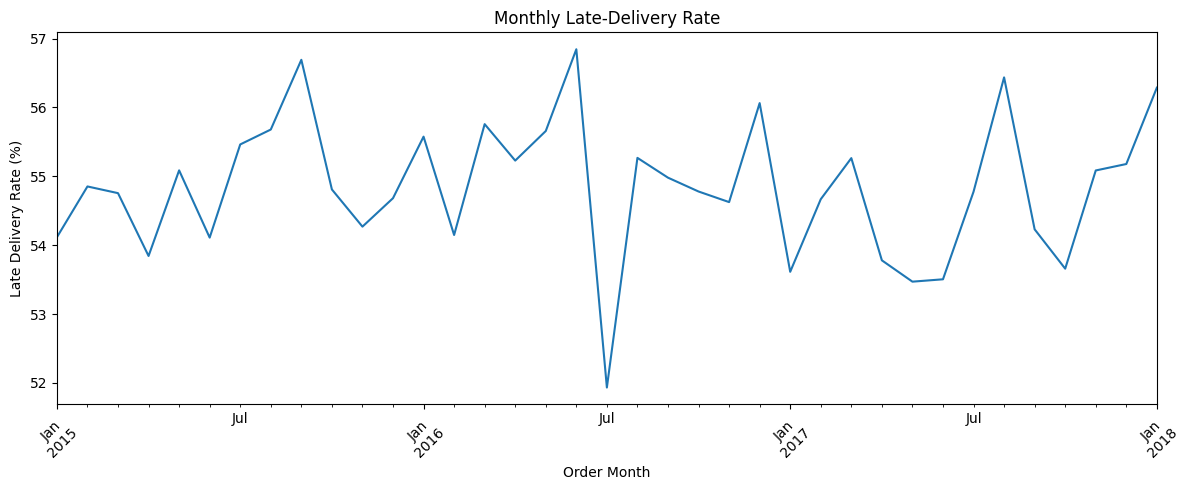

In [307]:
monthly_late_rate.plot(figsize=(12, 5))

plt.title('Monthly Late-Delivery Rate')
plt.xlabel('Order Month')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [308]:
sales_by_region = (
    df.groupby('Order Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

sales_by_region.round(2)

Order Region
Western Europe     5894380.77
Central America    5665712.10
South America      2960881.41
Northern Europe    2155830.65
Southern Europe    2047918.82
Oceania            2016654.20
Southeast Asia     1932495.57
Caribbean          1651019.33
West of USA        1571415.96
South Asia         1553680.92
Eastern Asia       1486401.34
East of USA        1371111.99
West Asia          1174671.78
US Center          1151355.77
South of  USA       785783.95
Eastern Europe      774266.57
West Africa         727951.19
North Africa        634752.22
East Africa         376234.90
Central Africa      327263.02
Southern Africa     228251.59
Canada              186861.04
Central Asia        109839.93
Name: Sales, dtype: float64

In [309]:
profit_by_region = (
    df.groupby('Order Region')['Order Profit Per Order']
    .sum()
    .sort_values(ascending=False)
)

profit_by_region.round(2)

Order Region
Western Europe     625446.08
Central America    616341.57
South America      335154.40
Northern Europe    233450.60
Southern Europe    230829.23
Southeast Asia     211342.82
Oceania            201478.02
Caribbean          171825.64
South Asia         165703.90
West of USA        164940.66
East of USA        156263.30
Eastern Asia       147368.01
US Center          131094.23
West Asia          118815.41
South of  USA       88114.88
West Africa         80030.27
Eastern Europe      79717.05
North Africa        64599.86
East Africa         43167.73
Central Africa      33447.27
Southern Africa     30826.05
Canada              23900.71
Central Asia        13045.28
Name: Order Profit Per Order, dtype: float64

In [310]:
sales_by_category = (
    df.groupby('Category Name')['Sales']
    .sum()
    .sort_values(ascending=False)
)

sales_by_category.round(2)

Category Name
Fishing                 6929653.69
Cleats                  4431942.78
Camping & Hiking        4118425.57
Cardio Equipment        3694843.20
Women's Apparel         3147800.00
Water Sports            3113844.68
Men's Footwear          2891757.66
Indoor/Outdoor Games    2888993.91
Shop By Sport           1309522.04
Computers                663000.00
Electronics              371034.64
Cameras                  267607.69
Garden                   257768.73
Children's Clothing      232829.20
Crafts                   223356.33
Girls' Apparel           151706.20
Women's Clothing         140283.00
Accessories              133671.51
Sporting Goods           117006.75
Golf Gloves              116695.39
Music                    113122.10
Consumer Electronics     108991.28
Golf Shoes               107998.00
Health and Beauty        106080.48
Kids' Golf Clubs          98797.58
Baseball & Softball       94057.15
Boxing & MMA              85205.41
DVDs                      79395.54
Golf B

In [311]:
profit_by_category = (
    df.groupby('Category Name')['Order Profit Per Order']
    .sum()
    .sort_values(ascending=False)
)

profit_by_category.round(2)

Category Name
Fishing                 756220.77
Cleats                  494636.92
Camping & Hiking        427455.57
Cardio Equipment        383011.10
Women's Apparel         350421.03
Water Sports            325146.96
Indoor/Outdoor Games    318451.43
Men's Footwear          311902.82
Shop By Sport           129813.96
Computers                69656.81
Electronics              40891.38
Garden                   33443.01
Cameras                  30289.80
Children's Clothing      27178.10
Crafts                   25531.17
Women's Clothing         19102.85
Girls' Apparel           17288.57
Accessories              16643.52
Music                    14436.32
Consumer Electronics     13223.40
Golf Gloves              12975.49
Baseball & Softball      12762.13
Sporting Goods           12518.61
Golf Shoes               12406.07
Health and Beauty         9493.63
Kids' Golf Clubs          9045.84
Boxing & MMA              8641.37
Golf Balls                8342.67
Trade-In                  7915.37


In [312]:
sales_by_category.head(5).round(2)

Category Name
Fishing             6929653.69
Cleats              4431942.78
Camping & Hiking    4118425.57
Cardio Equipment    3694843.20
Women's Apparel     3147800.00
Name: Sales, dtype: float64

In [313]:
profit_by_category.head(5).round(2)

Category Name
Fishing             756220.77
Cleats              494636.92
Camping & Hiking    427455.57
Cardio Equipment    383011.10
Women's Apparel     350421.03
Name: Order Profit Per Order, dtype: float64

In [314]:
profit_by_shipping = (
    df.groupby('Shipping Mode')['Order Profit Per Order']
    .mean()
    .sort_values(ascending=False)
)

profit_by_shipping.round(2)

Shipping Mode
First Class       23.12
Standard Class    22.00
Second Class      21.31
Same Day          20.85
Name: Order Profit Per Order, dtype: float64

In [315]:
sales_by_shipping = (
    df.groupby('Shipping Mode')['Sales']
    .mean()
    .sort_values(ascending=False)
)

sales_by_shipping.round(2)

Shipping Mode
Standard Class    204.38
First Class       204.01
Second Class      202.90
Same Day          199.50
Name: Sales, dtype: float64

In [316]:
profit_by_segment = (
    df.groupby('Customer Segment')['Order Profit Per Order']
    .mean()
    .sort_values(ascending=False)
)

profit_by_segment.round(2)

Customer Segment
Consumer       22.18
Corporate      21.95
Home Office    21.44
Name: Order Profit Per Order, dtype: float64

In [317]:
sales_by_segment = (
    df.groupby('Customer Segment')['Sales']
    .mean()
    .sort_values(ascending=False)
)

sales_by_segment.round(2)

Customer Segment
Consumer       204.22
Corporate      203.84
Home Office    202.34
Name: Sales, dtype: float64

In [318]:
category_summary = df.groupby('Category Name').agg(
    Late_Delivery_Rate=('Late_delivery_risk', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Order Profit Per Order', 'sum')
)

category_summary['Late_Delivery_Rate'] *= 100

category_summary.round(2)

,Late_Delivery_Rate,Total_Sales,Total_Profit
Category Name,,,
Accessories,56.97,133671.51,16643.52
As Seen on TV!,57.35,20597.94,714.43
Baby,52.66,12229.56,1525.03
Baseball & Softball,55.22,94057.15,12762.13
Basketball,55.22,27099.33,1845.67
Books,56.54,12587.40,883.01
Boxing & MMA,56.26,85205.41,8641.37
CDs,52.03,3059.59,383.85
Cameras,58.11,267607.69,30289.80


In [319]:
category_summary.sort_values(
    'Late_Delivery_Rate',
    ascending=False
).round(2)

,Late_Delivery_Rate,Total_Sales,Total_Profit
Category Name,,,
Golf Bags & Carts,68.85,10369.39,1810.07
Lacrosse,60.06,39464.79,4364.29
Pet Supplies,58.94,41524.80,3589.26
Cameras,58.11,267607.69,30289.80
Strength Training,57.66,54895.53,332.31
As Seen on TV!,57.35,20597.94,714.43
Music,57.14,113122.10,14436.32
Accessories,56.97,133671.51,16643.52
Fitness Accessories,56.96,35601.44,5258.39


In [320]:
df['Order Id'].nunique()

65752

In [321]:
df['Late_delivery_risk'].mean() * 100

np.float64(54.82913155955883)

In [322]:
df['Shipping_Delay_Days'].mean()

np.float64(0.5658074773292562)

In [323]:
df['Sales'].sum()

np.float64(36784735.01337984)

In [324]:
df['Order Profit Per Order'].sum()

np.float64(3966902.974050357)

In [325]:
total_orders = df['Order Id'].nunique()
total_orders

65752

In [326]:
late_delivery_rate = df['Late_delivery_risk'].mean() * 100
late_delivery_rate

np.float64(54.82913155955883)

In [327]:
avg_shipping_delay = df['Shipping_Delay_Days'].mean()
avg_shipping_delay

np.float64(0.5658074773292562)

In [328]:
total_sales = df['Sales'].sum()
total_sales

np.float64(36784735.01337984)

In [329]:
total_profit = df['Order Profit Per Order'].sum()
total_profit

np.float64(3966902.974050357)

## Export Cleaned Dataset

The cleaned dataset is exported for use in exploratory analysis and dashboard development.

In [330]:
df.to_csv("../data/processed/supply_chain_clean.csv", index=False)

In [331]:
import os

os.path.exists("../data/processed/supply_chain_clean.csv")

True